# Explore here

Análisis de sentimientos
Los modelos Naive Bayes son muy útiles cuando queremos analizar sentimientos, clasificar textos en tópicos o recomendaciones, ya que las características de estos desafíos cumplen muy bien con los supuestos teóricos y metodológicos del modelo.


En este proyecto practicarás con un conjunto de datos para crear un clasificador de reseñas de la tienda de Google Play.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre playstore_reviews.csv. Puedes cargarlo en el código directamente desde el sigiente enlace:


https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

package_name. Nombre de la aplicación móvil (categórico)
review. Comentario sobre la aplicación móvil (categórico)
polarity. Variable de clase (0 o 1), siendo 0 un comentario negativo y 1, positivo (categórico numérico)

In [50]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.datasets import fetch_20newsgroups

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB

import warnings

url="https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"


df= pd.read_csv(url)
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


Paso 2. 

En este caso, tenemos solo 3 variables: 2 predictoras y una etiqueta dicotómica. De las dos predictoras, realmente solo nos interesa la parte del comentario, ya que el hecho de clasificar un comentario en positivo o negativo dependerá de su contenido, no de la aplicación de la que se haya escrito. Por lo tanto, la variable package_name habría que eliminarla.

Cuando trabajamos con textos como en este caso, no tiene sentido hacer un EDA, el proceso es diferente, ya que la única variable que nos interesa es la que contiene el texto. En otros casos en los que el texto formase parte de un conjunto complejo con otras variables predictoras numéricas y el objetivo de predicción sea distinto, entonces tiene sentido aplicar un EDA.

In [51]:
df.drop(["package_name"], axis = 1, inplace = True)

df.head()

,review,polarity
0,privacy at least put some option appear offli...,0
1,"messenger issues ever since the last update, ...",0
2,profile any time my wife or anybody has more ...,0
3,the new features suck for those of us who don...,0
4,forced reload on uploading pic on replying co...,0


In [52]:
df.shape

(891, 2)

In [72]:
df.polarity.value_counts()

polarity
0    584
1    307
Name: count, dtype: int64

Sin embargo, no podemos trabajar con texto plano, antes hay que procesarlo. Este proceso consta de varios pasos:

1. Eliminar espacios y convertir a minúsculas el texto:

In [53]:
df["review"] = df["review"].str.strip().str.lower()

df.head(10)

,review,polarity
0,privacy at least put some option appear offlin...,0
1,"messenger issues ever since the last update, i...",0
2,profile any time my wife or anybody has more t...,0
3,the new features suck for those of us who don'...,0
4,forced reload on uploading pic on replying com...,0
5,idk i can't edit my posts? things such as my p...,0
6,major flaws constant updates and always gettin...,0
7,video issues since i was forced into this upda...,0
8,this update completely destroyed my facebook. ...,0
9,"posting issues for the last week, there's been...",0


2. Dividir el conjunto de datos en train y test: X_train, X_test, y_train, y_test

In [54]:
X= df["review"]       #variable predictora
y=df["polarity"]               #variable objetivo


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.head()

331    just did the latest update on viber and yet ag...
733    keeps crashing it only works well in extreme d...
382    the fail boat has arrived the 6.0 version is t...
704    superfast, just as i remember it ! opera mini ...
813    installed and immediately deleted this crap i ...
Name: review, dtype: str

In [55]:
X_train.shape, X_test.shape

((712,), (179,))

3. Transformar el texto en una matriz de recuento de palabras. Esta es una forma de obtener características numéricas a partir del texto. Para ello, utilizamos el conjunto de train para entrenar el transformador y la aplicamos en test:

In [56]:
vec_model = CountVectorizer(stop_words = "english")
X_train = vec_model.fit_transform(X_train).toarray()
X_test = vec_model.transform(X_test).toarray()

Paso 3: Construye un naive bayes

MODELADO

GaussianNB

In [57]:
# modelo
model = GaussianNB()

# entrenamiento
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [58]:
# predicción
y_pred_train = model.predict(X_train)

y_pred_test = model.predict(X_test)
y_pred_test

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0])

In [59]:
X_test.shape

(179, 3310)

In [60]:
# metricas
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)


Accuracy Test:  0.8044692737430168
Accuracy Train:  0.9859550561797753


Conclusiones:

Se obbtuvo un valor accuracy test de 0.80 y el valor de accuracy train fue de 0.98, muy cerca a 1. Se puede decir que el modelo aprendió demasiado la data de entrenamiento pero esto puede afectar al modelo cuando evalua la data test, por lo que esto explica porque el accuracy test salió 0.80. Existe cierto overfitting.

Sin embargo, se considera que el modelo es aceptable para el análisis de sentimientos.

A continuación, se realizarán los demás modelos.

MODELO MultinomialNB

In [61]:
# modelo
model_multinomial = MultinomialNB()

# entrenamiento
model_multinomial.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [62]:

y_pred_train_multinomial = model_multinomial.predict(X_train)
y_pred_test_multinomial = model_multinomial.predict(X_test)
y_pred_test_multinomial

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0])

In [63]:
print("Accuracy train:", accuracy_score(y_train, y_pred_train_multinomial))
print("Accuracy test:", accuracy_score(y_test, y_pred_test_multinomial))
print("="*80)
print(classification_report(y_test, y_pred_test_multinomial))

Accuracy train: 0.9606741573033708
Accuracy test: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       126
           1       0.73      0.60      0.66        53

    accuracy                           0.82       179
   macro avg       0.79      0.75      0.77       179
weighted avg       0.81      0.82      0.81       179



Conclusiones:
Se obtuvo un valor accuracy test de 0.82 y el valor de accuracy train fue de 0.96, muy cerca a 1. 
Similar a los rsultados del modelo gaussian, se puede decir que el modelo aprendió demasiado la data de entrenamiento pero esto puede afectar al modelo cuando evalua la data test, por lo que esto explica porque el accuracy test salió 0.82. Existe cierto overfitting.

Sin embargo, se considera que el modelo es aceptable y mejor para el análisis de sentimientos comparado al modelo gaussian. 


MODELADO-BernoulliNB

In [64]:
model_bernoulli = BernoulliNB()

model_bernoulli.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [65]:
y_pred_train_bernoulli = model_bernoulli.predict(X_train)
y_pred_test_bernoulli = model_bernoulli.predict(X_test)
y_pred_test_bernoulli

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0])

In [66]:
print("Accuracy train:", accuracy_score(y_train, y_pred_train_bernoulli))
print("Accuracy test:", accuracy_score(y_test, y_pred_test_bernoulli))
print("="*80)
print(classification_report(y_test, y_pred_test_bernoulli))

Accuracy train: 0.9199438202247191
Accuracy test: 0.770949720670391
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       126
           1       0.70      0.40      0.51        53

    accuracy                           0.77       179
   macro avg       0.74      0.66      0.68       179
weighted avg       0.76      0.77      0.75       179



Conclusiones finales de 3 modelos implementados:

El modelo bernoulli tiene un nvalor accuracy test y train de 0.77 y 0.92 respectivamente. Aunque aquí se visualiza cierto overfitting, este modelo presentó un menor rendimiento en test comparado a gaussian y multinomial.

Se puede decir que de los 3 modelos que se usaron para clasificar comentarios com opositivos o negativos.  El modelo multinomial presentó mejor rendimiento (accuracytest 0.82).

El modelo gaussian presentó resultados aceptables pero tiene mayor overfitting. Por otro lado, bernoulli fue el modelo con menor rendimiento.


OPTIMIZAR MODELO

Se utilizará random forest para ver si se obtienen mejores resultados

In [ ]:
# modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
# entrenamiento
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

print("Accuracy train:", accuracy_score(y_train, y_pred_train_rf))
print("Accuracy test:", accuracy_score(y_test, y_pred_test_rf))
print(classification_report(y_test, y_pred_test_rf))

Accuracy train: 0.7556179775280899
Accuracy test: 0.7318435754189944
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       126
           1       1.00      0.09      0.17        53

    accuracy                           0.73       179
   macro avg       0.86      0.55      0.51       179
weighted avg       0.81      0.73      0.64       179



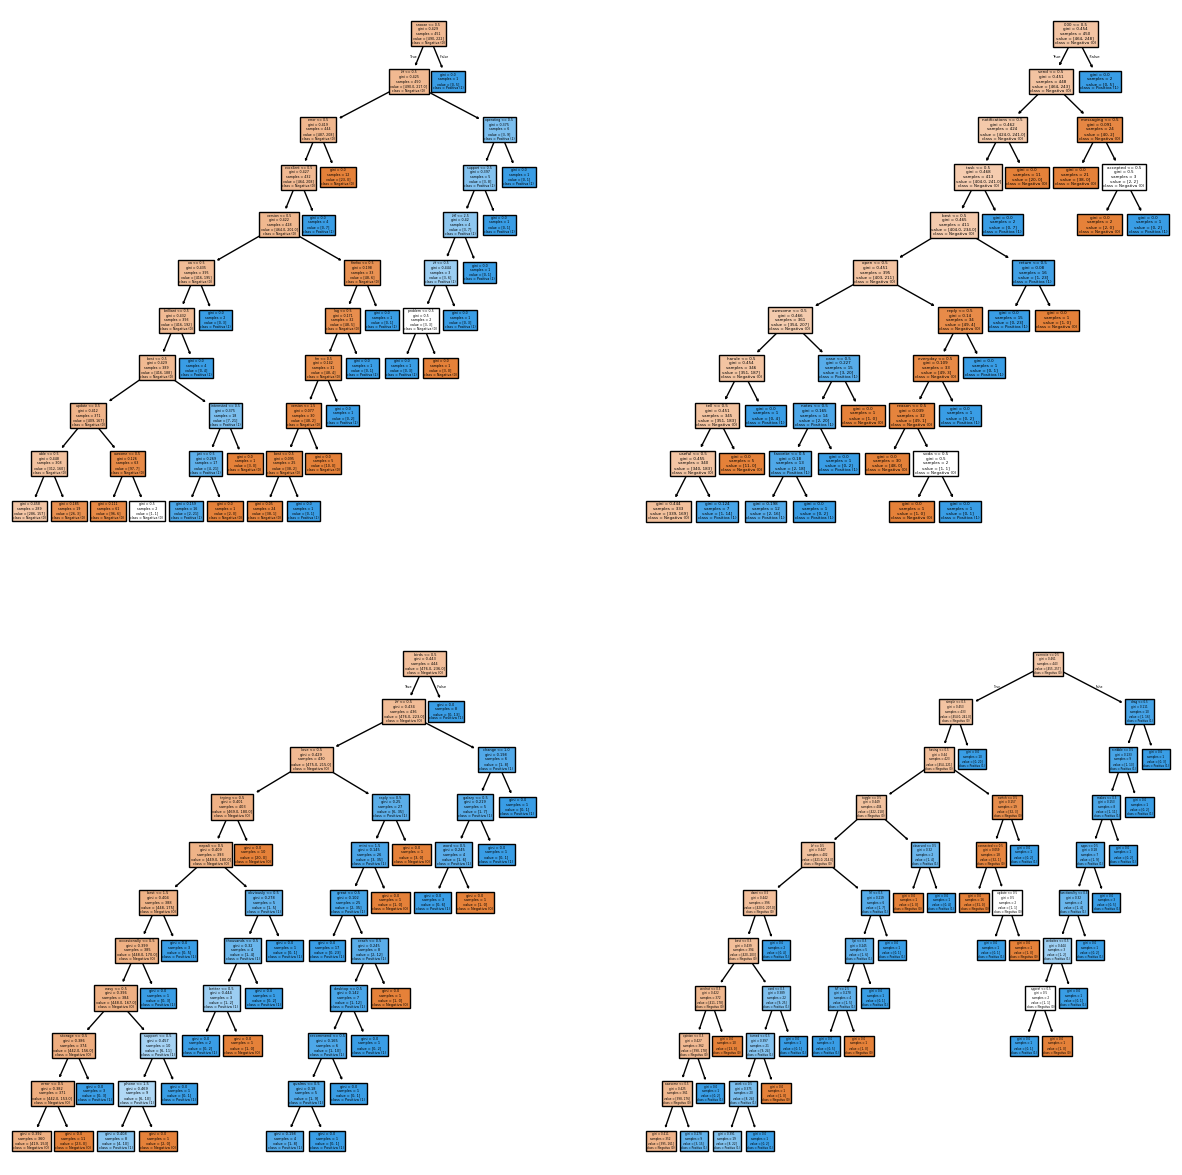

In [ ]:
from sklearn import tree


fig, axis = plt.subplots(2, 2, figsize = (15, 15))

clases = ["Negativa (0)", "Positiva (1)"]

tree.plot_tree(rf_model.estimators_[0],
    ax = axis[0, 0],
    feature_names = vec_model.get_feature_names_out(),
    class_names = clases,
    filled = True
)

tree.plot_tree(
    rf_model.estimators_[1],
    ax = axis[0, 1],
    feature_names = vec_model.get_feature_names_out(),
    class_names = clases,
    filled = True
)

tree.plot_tree(
    rf_model.estimators_[2],
    ax = axis[1, 0],
    feature_names = vec_model.get_feature_names_out(),
    class_names = clases,
    filled = True
)

tree.plot_tree(
    rf_model.estimators_[3],
    ax = axis[1, 1],
    feature_names = vec_model.get_feature_names_out(),
    class_names = clases,
    filled = True
)

plt.show()

Conclusiones:

El modelo obtuvo un accuracy test de 0.73, el resultado es menor al de los 3 modelos usados antes. 
Además, se tiene un recall de 0.09 en la clase positiva, lo cual es muy bajo para predecir los comentarios positivos.

Por lo que se entiende que no se puede optimizar el modelo con random forest. 
Si bien esta técnica ayuda para problemas de clasificación, en este caso no aplica porque no superó el rendimiento del modelo multinomial. Puede deberse porque el ejercicio implica revisar frecuencia de palabras. 
Finalmente, el modelo multinomial sigue siendo la mejor opción.
